# Intención de compra: de los datos a la evaluación
**Mateo Sapia · Data Science 1 · Comisión 102390 · 30/09/2026**

## Resumen
Este estudio compara regresión logística y Random Forest para clasificar retrospectivamente si una sesión terminó en compra. Sobre 2,434 observaciones de test, el candidato elegido por CV fue **Random Forest**, con **F1 0.429 y AP 0.378**. Después de retirar 125 repeticiones exactas, se modelaron 12,167 patrones. Las predicciones describen este archivo histórico; no constituyen un sistema validado para intervenir durante una visita.

## Contexto y método
Unidad: una sesión. Objetivo: `Revenue` (compra = 1). Se busca priorizar qué patrones merecen investigación de negocio; no inferir que prolongar la navegación cause ventas.

### Supuestos y límites
- Se continúa el dataset UCI usado en las preentregas. Se excluyen sesiones sin páginas de producto y `PageValues`, por posible fuga de información.
- Los campos agregan la sesión completa. No están todos disponibles al inicio; un uso en tiempo real requeriría nuevos datos y otro diseño temporal.
- No hay ID de persona ni fecha completa: no se puede garantizar independencia entre usuarios ni una evaluación temporal. Se agrupan patrones idénticos de predictores para no repartirlos entre train/test.
- La etapa anterior conservó repeticiones. Aquí se deduplican filas exactamente iguales como decisión de modelado conservadora, sin afirmar que fueran eventos duplicados reales. Se cuantifica el cambio de población.
- El test se reserva con antelación. Los hiperparámetros se eligen por Average Precision en validación cruzada del train, sin ajustarlos al test.

## 1. Datos y trazabilidad
Fuente: Sakar, C. y Kastro, Y. (2018), [Online Shoppers Purchasing Intention, UCI](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), DOI [10.24432/C5F88Q](https://doi.org/10.24432/C5F88Q), CC BY 4.0. Descarga original: 29/09/2026. La fuente describe sesiones históricas de un año; el CSV no permite reconstruir una fecha calendario por fila.
El CSV original se incluye. Si se abre solo este notebook en Colab, se descarga el mismo archivo público y se verifica su SHA-256.

In [1]:
from pathlib import Path
import hashlib, io, zipfile, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
SEED=42
FIG=Path('figuras'); FIG.mkdir(exist_ok=True)
path=Path('data/online_shoppers_intention.csv')
if not path.exists():
    url='https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip'
    with urllib.request.urlopen(url,timeout=60) as response:
        with zipfile.ZipFile(io.BytesIO(response.read())) as archive:
            payload=archive.read('online_shoppers_intention.csv')
    path.parent.mkdir(exist_ok=True);path.write_bytes(payload)
assert hashlib.sha256(path.read_bytes()).hexdigest()=='b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9'
raw=pd.read_csv(path)
print('Original:',raw.shape,'| nulos:',int(raw.isna().sum().sum()),'| repeticiones:',int(raw.duplicated().sum()))
display(raw.head(3).T)

Original: (12330, 18) | nulos: 0 | repeticiones: 125


,0,1,2
Administrative,0,0,0
Administrative_Duration,0.0,0.0,0.0
Informational,0,0,0
Informational_Duration,0.0,0.0,0.0
ProductRelated,1,2,1
ProductRelated_Duration,0.0,64.0,0.0
BounceRates,0.2,0.0,0.2
ExitRates,0.2,0.1,0.2
PageValues,0.0,0.0,0.0
SpecialDay,0.0,0.0,0.0


## 2. Limpieza y selección
Se conservan ceros válidos. Las edades o fechas inexistentes no se inventan. Los valores extremos de navegación no se eliminan por un percentil arbitrario. Los códigos de sistema, navegador, región y tráfico se tratan como categorías, no como cantidades. El pipeline incluye imputadores para robustez futura, aunque el archivo actual no presenta nulos.

In [2]:
conteos=['Administrative','Administrative_Duration','Informational','Informational_Duration','ProductRelated','ProductRelated_Duration']
tasas=['BounceRates','ExitRates','SpecialDay']
validos=(raw[conteos].ge(0).all(axis=1) & np.isfinite(raw[conteos]).all(axis=1)
         & raw[tasas].ge(0).all(axis=1) & raw[tasas].le(1).all(axis=1))
saneado=raw.loc[validos & raw.ProductRelated.gt(0)].drop(columns='PageValues').copy()
duplicados=int(saneado.duplicated().sum())
df=saneado.drop_duplicates().reset_index(drop=True)
assert saneado.shape==(12292,17)
assert df.isna().sum().sum()==0 and 'PageValues' not in df
auditoria=pd.DataFrame([
    ['Original',len(raw),int(raw.Revenue.sum())],
    ['Con productos; sin PageValues',len(saneado),int(saneado.Revenue.sum())],
    ['Patrones exactos sin repetición',len(df),int(df.Revenue.sum())]
],columns=['Etapa','Filas','Compras'])
display(auditoria)
display(df[conteos+tasas].describe().T.round(3))
print('Repeticiones retiradas después del saneamiento:',duplicados)
print('Tasa de compra: antes',round(saneado.Revenue.mean(),5),'después',round(df.Revenue.mean(),5))

,Etapa,Filas,Compras
0,Original,12330,1908
1,Con productos; sin PageValues,12292,1902
2,Patrones exactos sin repetición,12167,1902


,count,mean,std,min,25%,50%,75%,max
Administrative,12167.0,2.343,3.334,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12167.0,81.832,177.710,0.0,0.000,9.000,95.000,3398.750
Informational,12167.0,0.509,1.277,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12167.0,34.927,141.633,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12167.0,32.146,44.627,1.0,8.000,18.000,38.000,705.000
ProductRelated_Duration,12167.0,1210.752,1921.410,0.0,196.500,612.750,1481.825,63973.522
BounceRates,12167.0,0.020,0.045,0.0,0.000,0.003,0.017,0.200
ExitRates,12167.0,0.041,0.046,0.0,0.014,0.025,0.048,0.200
SpecialDay,12167.0,0.062,0.200,0.0,0.000,0.000,0.000,1.000


Repeticiones retiradas después del saneamiento: 125
Tasa de compra: antes 0.15473 después 0.15632


## 3. EDA visual
Los gráficos de esta sección usan las **12.292 sesiones saneadas del checkpoint previo**, para mantener continuidad con la preentrega visual. El modelado de la sección 4 usa la versión deduplicada. Son asociaciones descriptivas, no relaciones causales.

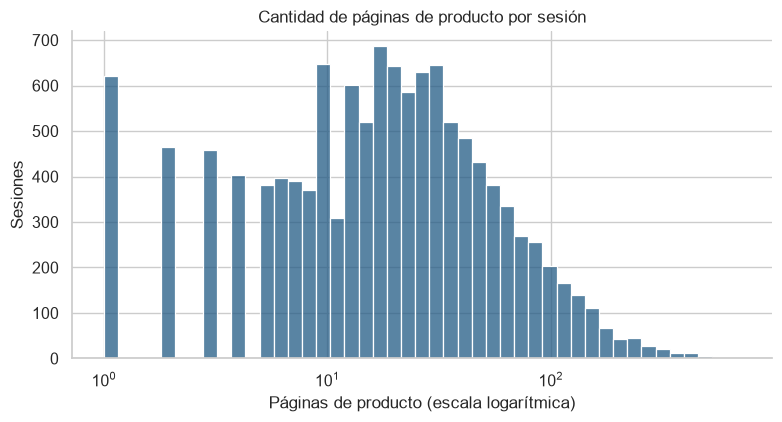

La mediana es **18 páginas**, frente a una media de **31.8** y un máximo de **705**. La cola derecha justifica comparar medianas y revisar extremos sin borrarlos automáticamente.

In [3]:
sns.set_theme(style='whitegrid',font_scale=1.05)
plt.rcParams.update({'figure.figsize':(8,4.4),'axes.spines.top':False,'axes.spines.right':False,'savefig.dpi':150})
def guardar(nombre):
    plt.tight_layout();plt.savefig(FIG/nombre,bbox_inches='tight');plt.show()
fig,ax=plt.subplots()
sns.histplot(data=saneado,x='ProductRelated',bins=45,log_scale=True,color='#225b85',ax=ax)
ax.set(title='Cantidad de páginas de producto por sesión',xlabel='Páginas de producto (escala logarítmica)',ylabel='Sesiones')
guardar('eda_1_paginas.png')
display(Markdown(f"La mediana es **{saneado.ProductRelated.median():.0f} páginas**, frente a una media de **{saneado.ProductRelated.mean():.1f}** y un máximo de **{saneado.ProductRelated.max():.0f}**. La cola derecha justifica comparar medianas y revisar extremos sin borrarlos automáticamente."))

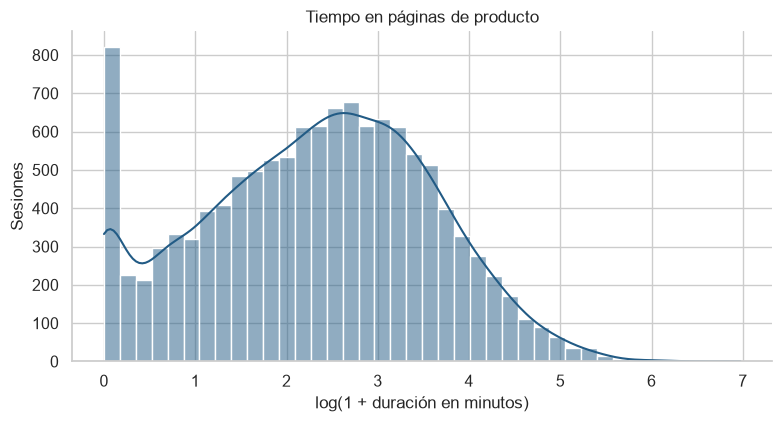

La duración mediana es **10.03 minutos** y la media **19.97**. La transformación del eje comprime valores grandes; no modifica los datos de origen.

In [4]:
fig,ax=plt.subplots()
# log1p permite conservar duraciones de cero sin descartarlas.
sns.histplot(np.log1p(saneado.ProductRelated_Duration/60),bins=40,kde=True,color='#225b85',ax=ax)
ax.set(title='Tiempo en páginas de producto',xlabel='log(1 + duración en minutos)',ylabel='Sesiones')
guardar('eda_2_duracion.png')
display(Markdown(f"La duración mediana es **{saneado.ProductRelated_Duration.median()/60:.2f} minutos** y la media **{saneado.ProductRelated_Duration.mean()/60:.2f}**. La transformación del eje comprime valores grandes; no modifica los datos de origen."))

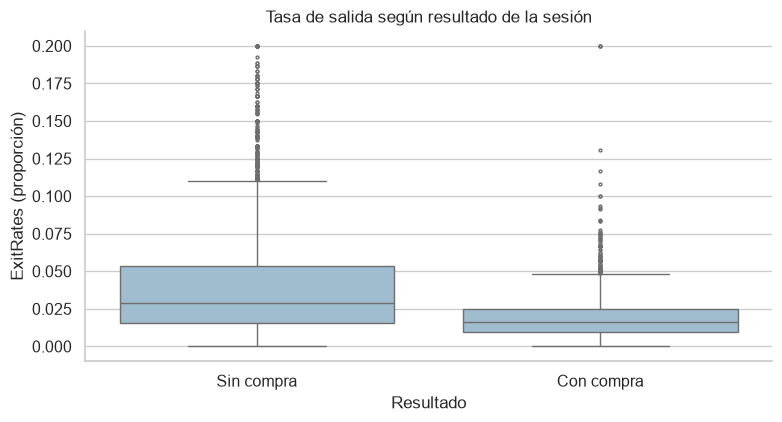

Las medianas de ExitRates son **0.0286** sin compra y **0.0159** con compra. Hay solapamiento y valores extremos; esta diferencia no prueba que modificar la tasa cause una compra.

In [5]:
plot=saneado.assign(Resultado=saneado.Revenue.map({False:'Sin compra',True:'Con compra'}))
fig,ax=plt.subplots()
sns.boxplot(data=plot,x='Resultado',y='ExitRates',order=['Sin compra','Con compra'],color='#98bdd7',fliersize=2,ax=ax)
ax.set(title='Tasa de salida según resultado de la sesión',xlabel='Resultado',ylabel='ExitRates (proporción)')
guardar('eda_3_boxplot.png')
medianas=saneado.groupby('Revenue').ExitRates.median()
display(Markdown(f"Las medianas de ExitRates son **{medianas[False]:.4f}** sin compra y **{medianas[True]:.4f}** con compra. Hay solapamiento y valores extremos; esta diferencia no prueba que modificar la tasa cause una compra."))

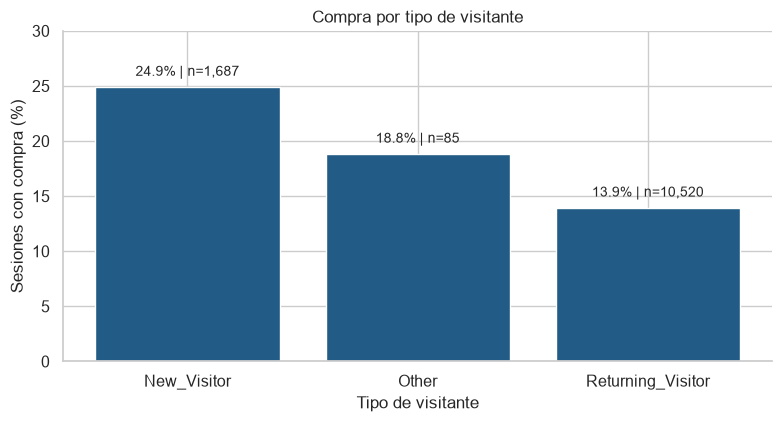

,sesiones,proporcion_compra
VisitorType,,
New_Visitor,1687,0.2490
Other,85,0.1882
Returning_Visitor,10520,0.1394


Las tasas se comparan con su denominador, no con ventas absolutas. El grupo Other tiene menos observaciones y su estimación es más inestable. El tipo de visitante no se interpreta como una causa del resultado.

In [6]:
grupos=saneado.groupby('VisitorType').Revenue.agg(['size','mean']).sort_values('mean',ascending=False)
fig,ax=plt.subplots()
bars=ax.bar(grupos.index,grupos['mean']*100,color='#225b85')
ax.bar_label(bars,labels=[f'{rate:.1%} | n={n:,}' for n,rate in grupos[['size','mean']].itertuples(index=False,name=None)],padding=6,fontsize=10)
ax.set(title='Compra por tipo de visitante',xlabel='Tipo de visitante',ylabel='Sesiones con compra (%)',ylim=(0,30))
guardar('eda_4_visitante.png')
display(grupos.rename(columns={'size':'sesiones','mean':'proporcion_compra'}).round(4))
display(Markdown('Las tasas se comparan con su denominador, no con ventas absolutas. El grupo Other tiene menos observaciones y su estimación es más inestable. El tipo de visitante no se interpreta como una causa del resultado.'))

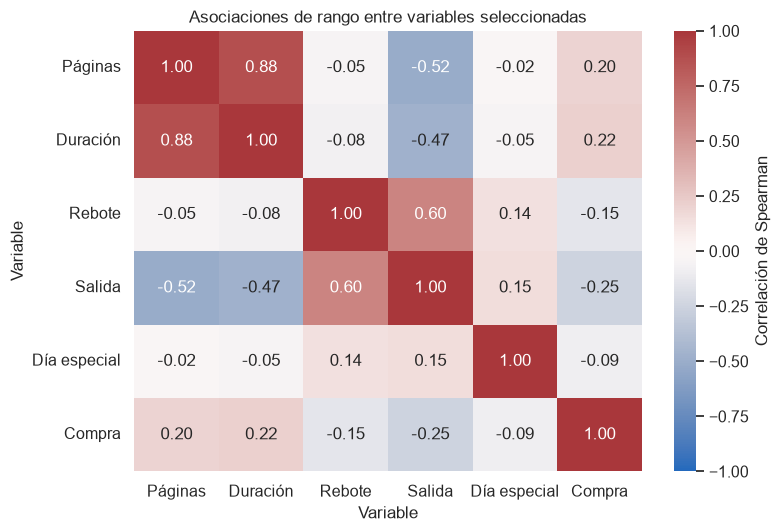

Páginas y duración están asociadas (Spearman **0.88**). Rebote y salida también (**0.60**). La redundancia puede afectar la interpretación individual; correlación no implica causalidad.

In [7]:
cols=['ProductRelated','ProductRelated_Duration','BounceRates','ExitRates','SpecialDay','Revenue']
corr=saneado[cols].corr(method='spearman')
fig,ax=plt.subplots(figsize=(8,5.5))
labels=['Páginas','Duración','Rebote','Salida','Día especial','Compra']
sns.heatmap(corr,annot=True,fmt='.2f',vmin=-1,vmax=1,center=0,cmap='vlag',xticklabels=labels,yticklabels=labels,ax=ax,cbar_kws={'label':'Correlación de Spearman'})
ax.set(title='Asociaciones de rango entre variables seleccionadas',xlabel='Variable',ylabel='Variable');ax.tick_params(axis='x',rotation=0);ax.tick_params(axis='y',rotation=0)
guardar('eda_5_correlacion.png')
display(Markdown(f"Páginas y duración están asociadas (Spearman **{corr.loc['ProductRelated','ProductRelated_Duration']:.2f}**). Rebote y salida también (**{corr.loc['BounceRates','ExitRates']:.2f}**). La redundancia puede afectar la interpretación individual; correlación no implica causalidad."))

## 4. Partición, variables y pipeline
Se usa aproximadamente 80 % para desarrollo y 20 % como test reservado. `StratifiedGroupKFold` intenta conservar la proporción de clases y mantiene cada patrón de predictores en un solo lado. Hashes se calculan **sin Revenue**; dos filas de entradas iguales con etiquetas distintas se mantienen en el mismo grupo.

Preprocesamiento dentro del pipeline: mediana + StandardScaler en numéricas; categoría frecuente + OneHotEncoder en nominales y Weekend. Fit se ejecuta dentro de cada fold. No se usan PageValues, Revenue, IDs de fila ni estadísticas del test como features.

In [8]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,confusion_matrix,roc_curve,precision_recall_curve)
from sklearn.base import clone
categoricas=['OperatingSystems','Browser','Region','TrafficType','Month','VisitorType','Weekend']
numericas=conteos+tasas
X=df.drop(columns='Revenue').copy();y=df.Revenue.astype(int)
for col in categoricas: X[col]=X[col].astype(str)
grupos_split=pd.util.hash_pandas_object(X,index=False).to_numpy()
outer=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED)
train_idx,test_idx=next(outer.split(X,y,grupos_split))
X_train,X_test=X.iloc[train_idx],X.iloc[test_idx]
y_train,y_test=y.iloc[train_idx],y.iloc[test_idx]
g_train,g_test=grupos_split[train_idx],grupos_split[test_idx]
assert not set(g_train)&set(g_test)
assert set(numericas+categoricas)==set(X.columns)
display(pd.DataFrame({'particion':['train','test'],'sesiones':[len(y_train),len(y_test)],'compras':[int(y_train.sum()),int(y_test.sum())],'proporcion_compra':[y_train.mean(),y_test.mean()]}).round(4))
prep=ColumnTransformer([
    ('num',Pipeline([('imputar',SimpleImputer(strategy='median')),('escalar',StandardScaler())]),numericas),
    ('cat',Pipeline([('imputar',SimpleImputer(strategy='most_frequent')),('codificar',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),categoricas)
])
inner=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=SEED+1)
splits=list(inner.split(X_train,y_train,g_train))
for a,b in splits: assert not set(g_train[a])&set(g_train[b])

,particion,sesiones,compras,proporcion_compra
0,train,9733,1521,0.1563
1,test,2434,381,0.1565


## 5. Comparación y selección en desarrollo
Base simple: regresión logística con C=1 y ponderación de clases. Ensamble: 150 árboles y una grilla acotada de profundidad y tamaño mínimo de hoja. Ambos se comparan con los mismos tres folds y Average Precision (AP), adecuada para evaluar el ranking de una clase minoritaria. AP no es el área trapezoidal de la curva PR. Accuracy y F1 se reportan, pero no sustituyen esa decisión previa.

In [9]:
logistica=Pipeline([('preparar',clone(prep)),('modelo',LogisticRegression(C=1,max_iter=2000,class_weight='balanced',random_state=SEED))])
rf=Pipeline([('preparar',clone(prep)),('modelo',RandomForestClassifier(n_estimators=150,class_weight='balanced_subsample',random_state=SEED,n_jobs=1))])
lr_cv=cross_val_score(logistica,X_train,y_train,cv=splits,scoring='average_precision',n_jobs=1)
busqueda=GridSearchCV(rf,{'modelo__max_depth':[6,12,None],'modelo__min_samples_leaf':[3,8]},cv=splits,scoring='average_precision',n_jobs=1,refit=True)
busqueda.fit(X_train,y_train)
logistica.fit(X_train,y_train)
modelos={'Regresión logística':logistica,'Random Forest':busqueda.best_estimator_}
seleccion_cv={'Regresión logística':float(lr_cv.mean()),'Random Forest':float(busqueda.best_score_)}
elegido=max(seleccion_cv,key=seleccion_cv.get)
display(pd.DataFrame({'Modelo':list(seleccion_cv),'AP media CV':list(seleccion_cv.values())}).round(4))
print('Desvío AP logística entre folds:',round(float(lr_cv.std()),4))
print('Mejor grilla RF:',busqueda.best_params_)
print('Candidato elegido solo con CV:',elegido)

,Modelo,AP media CV
0,Regresión logística,0.3224
1,Random Forest,0.3769


Desvío AP logística entre folds: 0.0026
Mejor grilla RF: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 8}
Candidato elegido solo con CV: Random Forest


## 6. Resultados en test reservado
Se usa umbral **0,50** fijado de antemano, sin optimizarlo contra el test. Precisión mide la proporción de compras entre predicciones positivas; recall, cuántas compras reales se detectan. F1 combina ambas. Se agrega el baseline que siempre predice no compra para mostrar el límite de accuracy.

In [10]:
filas=[];probabilidades={};matrices={}
for nombre,modelo in modelos.items():
    prob=modelo.predict_proba(X_test)[:,1];pred=(prob>=.5).astype(int)
    probabilidades[nombre]=prob;matrices[nombre]=confusion_matrix(y_test,pred,labels=[0,1]).tolist()
    filas.append({'Modelo':nombre,'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,zero_division=0),'Recall':recall_score(y_test,pred),'F1':f1_score(y_test,pred),'ROC_AUC':roc_auc_score(y_test,prob),'AP':average_precision_score(y_test,prob)})
metricas=pd.DataFrame(filas)
display(metricas.round(4))
print('Baseline siempre no compra: accuracy =',round(float((y_test==0).mean()),4),'; F1 = 0; AP de score constante =',round(float(y_test.mean()),4))
metricas.to_csv('metricas_test.csv',index=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,AP
0,Regresión logística,0.6495,0.2709,0.7323,0.3955,0.7420,0.3136
1,Random Forest,0.7671,0.3480,0.5591,0.4290,0.7783,0.3782


Baseline siempre no compra: accuracy = 0.8435 ; F1 = 0; AP de score constante = 0.1565


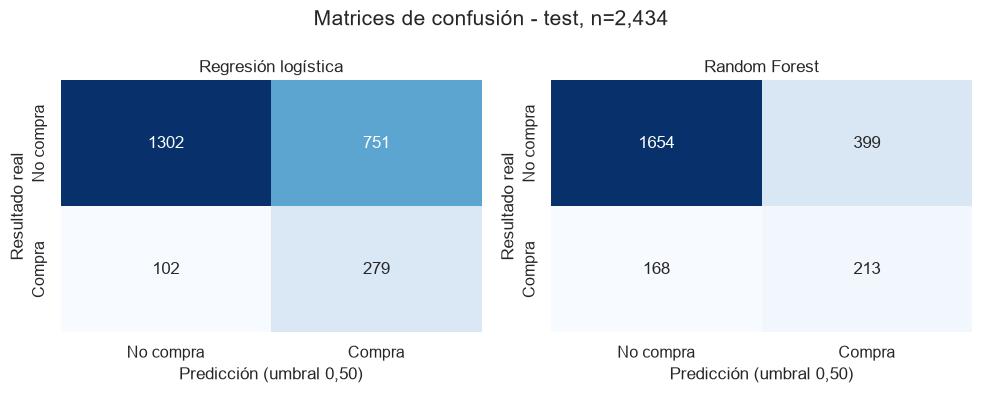

In [11]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,(nombre,matriz) in zip(axes,matrices.items()):
    sns.heatmap(matriz,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=['No compra','Compra'],yticklabels=['No compra','Compra'],ax=ax)
    ax.set(title=nombre,xlabel='Predicción (umbral 0,50)',ylabel='Resultado real')
fig.suptitle(f'Matrices de confusión - test, n={len(y_test):,}')
guardar('modelos_confusion.png')

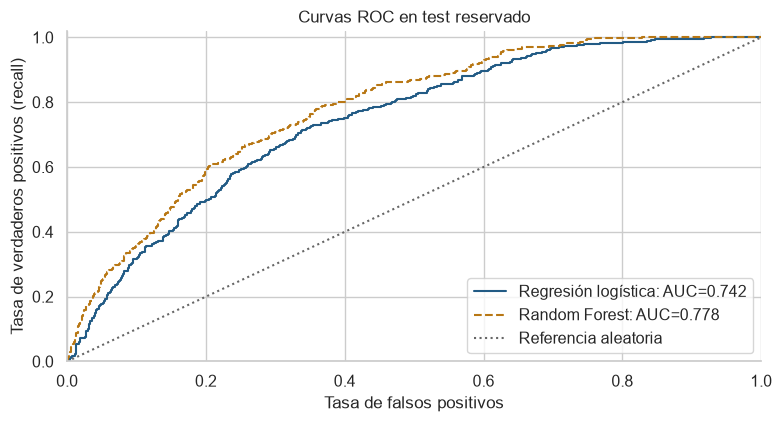

In [12]:
fig,ax=plt.subplots()
for (nombre,prob),color,estilo in zip(probabilidades.items(),['#225b85','#b87714'],['-','--']):
    fpr,tpr,_=roc_curve(y_test,prob)
    ax.plot(fpr,tpr,color=color,linestyle=estilo,label=f'{nombre}: AUC={roc_auc_score(y_test,prob):.3f}')
ax.plot([0,1],[0,1],':',color='#666666',label='Referencia aleatoria')
ax.set(title='Curvas ROC en test reservado',xlabel='Tasa de falsos positivos',ylabel='Tasa de verdaderos positivos (recall)',xlim=(0,1),ylim=(0,1.02));ax.legend(loc='lower right')
guardar('modelos_roc.png')

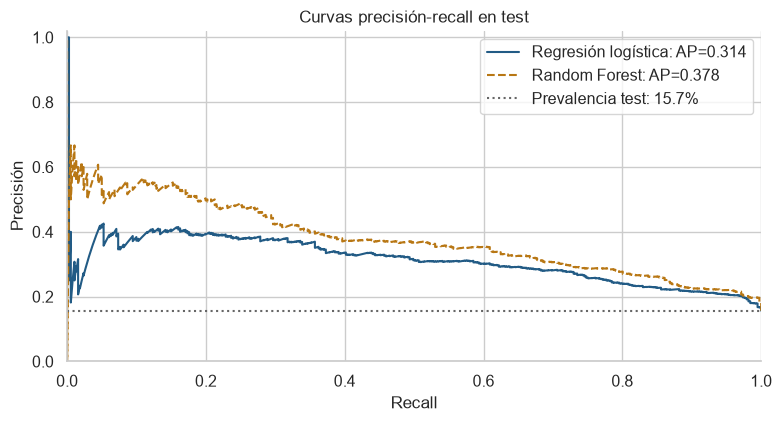

In [13]:
fig,ax=plt.subplots()
for (nombre,prob),color,estilo in zip(probabilidades.items(),['#225b85','#b87714'],['-','--']):
    precision,recall,_=precision_recall_curve(y_test,prob)
    ax.plot(recall,precision,color=color,linestyle=estilo,label=f'{nombre}: AP={average_precision_score(y_test,prob):.3f}')
ax.axhline(y_test.mean(),linestyle=':',color='#666666',label=f'Prevalencia test: {y_test.mean():.1%}')
ax.set(title='Curvas precisión-recall en test',xlabel='Recall',ylabel='Precisión',xlim=(0,1),ylim=(0,1.02));ax.legend()
guardar('modelos_pr.png')

## 7. Conclusiones y recomendación
El candidato se elige por AP de validación cruzada. El test documenta su comportamiento fuera del entrenamiento, sin cambiar después la elección. Se recomienda un **piloto retrospectivo supervisado**, con validación temporal y de disponibilidad de variables antes de una implementación operativa.

En un supuesto de asistencia de bajo costo para identificar intención de compra, un falso negativo deja una sesión con compra sin detectar; un falso positivo consume atención en una sesión sin compra. No se conocen costos ni efecto causal de una intervención, por lo que no se promete retorno económico. Si se necesitara mayor recall, se elegiría otro umbral en validación y se evaluaría una sola vez en un nuevo test.

In [14]:
fila=metricas.set_index('Modelo').loc[elegido]
tn,fp,fn,tp=np.asarray(matrices[elegido]).ravel()
display(Markdown(f"**{elegido}** obtuvo AP media CV **{seleccion_cv[elegido]:.3f}**. En test: AP **{fila.AP:.3f}**, AUC **{fila.ROC_AUC:.3f}**, precisión **{fila.Precision:.3f}**, recall **{fila.Recall:.3f}** y F1 **{fila.F1:.3f}**. Con umbral 0,50, produjo **{tp} aciertos positivos, {fp} falsos positivos y {fn} falsos negativos**. Estos valores no miden un aumento causal de ventas."))
resumen={'fecha':'2026-09-30','original':len(raw),'saneado':len(saneado),'deduplicado':len(df),'repeticiones_retiradas':duplicados,'compras_saneado':int(saneado.Revenue.sum()),'compras_deduplicado':int(df.Revenue.sum()),'train':len(y_train),'test':len(y_test),'compras_test':int(y_test.sum()),'ap_cv':seleccion_cv,'rf_parametros':busqueda.best_params_,'elegido':elegido,'metricas':filas,'matrices':matrices,'grupos_train_test_disjuntos':True}
Path('resultados_final.json').write_text(json.dumps(resumen,ensure_ascii=False,indent=2),encoding='utf-8')
assert all(sum(map(sum,matriz))==len(y_test) for matriz in matrices.values())
print('Verificado: matrices reconciliadas y grupos disjuntos; resultados guardados.')

**Random Forest** obtuvo AP media CV **0.377**. En test: AP **0.378**, AUC **0.778**, precisión **0.348**, recall **0.559** y F1 **0.429**. Con umbral 0,50, produjo **213 aciertos positivos, 399 falsos positivos y 168 falsos negativos**. Estos valores no miden un aumento causal de ventas.

Verificado: matrices reconciliadas y grupos disjuntos; resultados guardados.


### Próximos pasos y límites
1. Registrar timestamps y disponibilidad exacta de cada feature; usar un corte de sesión antes de la decisión si se busca intervenir.
2. Validar sobre un período posterior y una tienda comparable. El archivo no garantiza representatividad de otros comercios ni de 2026.
3. Comparar sensibilidad de resultados a deduplicación y política de sesiones sin productos. No hay IDs para identificar repeticiones reales de personas.
4. Determinar costos de falsos positivos/negativos y capacidad de atención; evaluar calibración y elegir umbral en validación independiente.
5. Solo después, medir el efecto de una intervención con un experimento controlado. No usar la correlación como prueba de impacto.

## Reproducibilidad y referencias
Ejecutar desde esta carpeta con `pip install -r requirements.txt` y «Restart & Run All». Todas las celdas usan semilla 42 o 43, rutas relativas y la fuente verificable. No hacen falta credenciales.

- [UCI: dataset, DOI y licencia](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset).
- [Scikit-learn: evitar fuga de información](https://scikit-learn.org/stable/common_pitfalls.html).
- [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).
- [Average Precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).